In [2]:
%reset -f
# %matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from osgeo import gdal, ogr, osr
# from pyproj import Proj, transform, CRS, Transformer
import matplotlib
# from parflow.tools.fs import get_absolute_path
# from parflow.tools.io import write_pfb, read_pfb
# from parflow.tools.hydrology import calculate_water_table_depth, calculate_overland_flow_grid

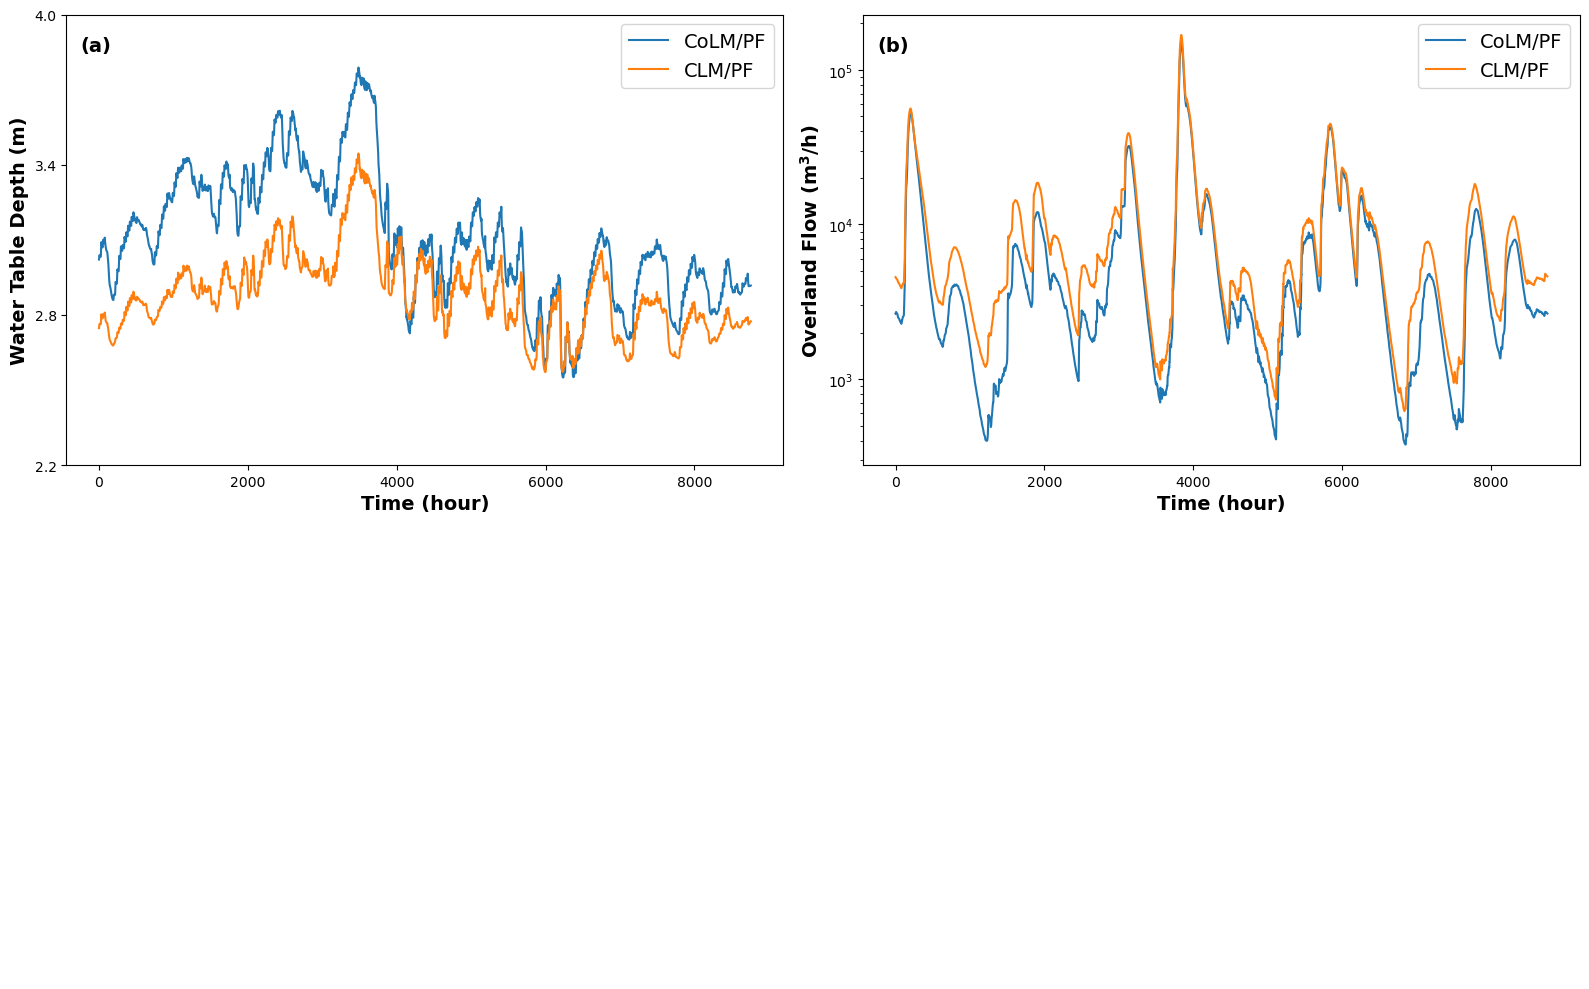

In [3]:
###FIGURE 5

n = 8760


newwtd = np.load('./for_plot_data/shallow_wtd_2nd.npy')
oldwtd = np.load('./for_plot_data/230_y2_wtd.npy')

newstr = np.load('./for_plot_data/shallow_str_2nd.npy')
oldstr = np.load('./for_plot_data/230_y2_overland_flow.npy')



# 创建图像和子图
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# (a) WTD 时间序列
axs[0, 0].plot(range(0, n), newwtd)
axs[0, 0].plot(range(0, n), oldwtd)
axs[0, 0].legend(['CoLM/PF', 'CLM/PF'], fontsize=14)
axs[0, 0].set_ylabel('Water Table Depth (m)', fontsize=14, fontweight='bold')
axs[0, 0].set_xlabel('Time (hour)', fontsize=14, fontweight='bold')
axs[0, 0].set_ylim([2.2, 4])
axs[0, 0].set_yticks([2.2, 2.8, 3.4, 4])
axs[0, 0].text(0.02, 0.92, '(a)', transform=axs[0, 0].transAxes, fontsize=14, fontweight='bold')

# (b) Overland Flow 对数图
axs[0, 1].semilogy(range(n), newstr)
axs[0, 1].semilogy(range(n), oldstr * 3600)
axs[0, 1].legend(['CoLM/PF', 'CLM/PF'], fontsize=14)
axs[0, 1].set_ylabel('Overland Flow ($\\mathregular{m^3}$/h)', fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel('Time (hour)', fontsize=14, fontweight='bold')
axs[0, 1].text(0.02, 0.92, '(b)', transform=axs[0, 1].transAxes, fontsize=14, fontweight='bold')

# 隐藏未使用的子图
axs[1, 0].axis('off')
axs[1, 1].axis('off')

# 布局调整
plt.tight_layout()
plt.show()

# fig.savefig('figure5.png', dpi=600, bbox_inches='tight')

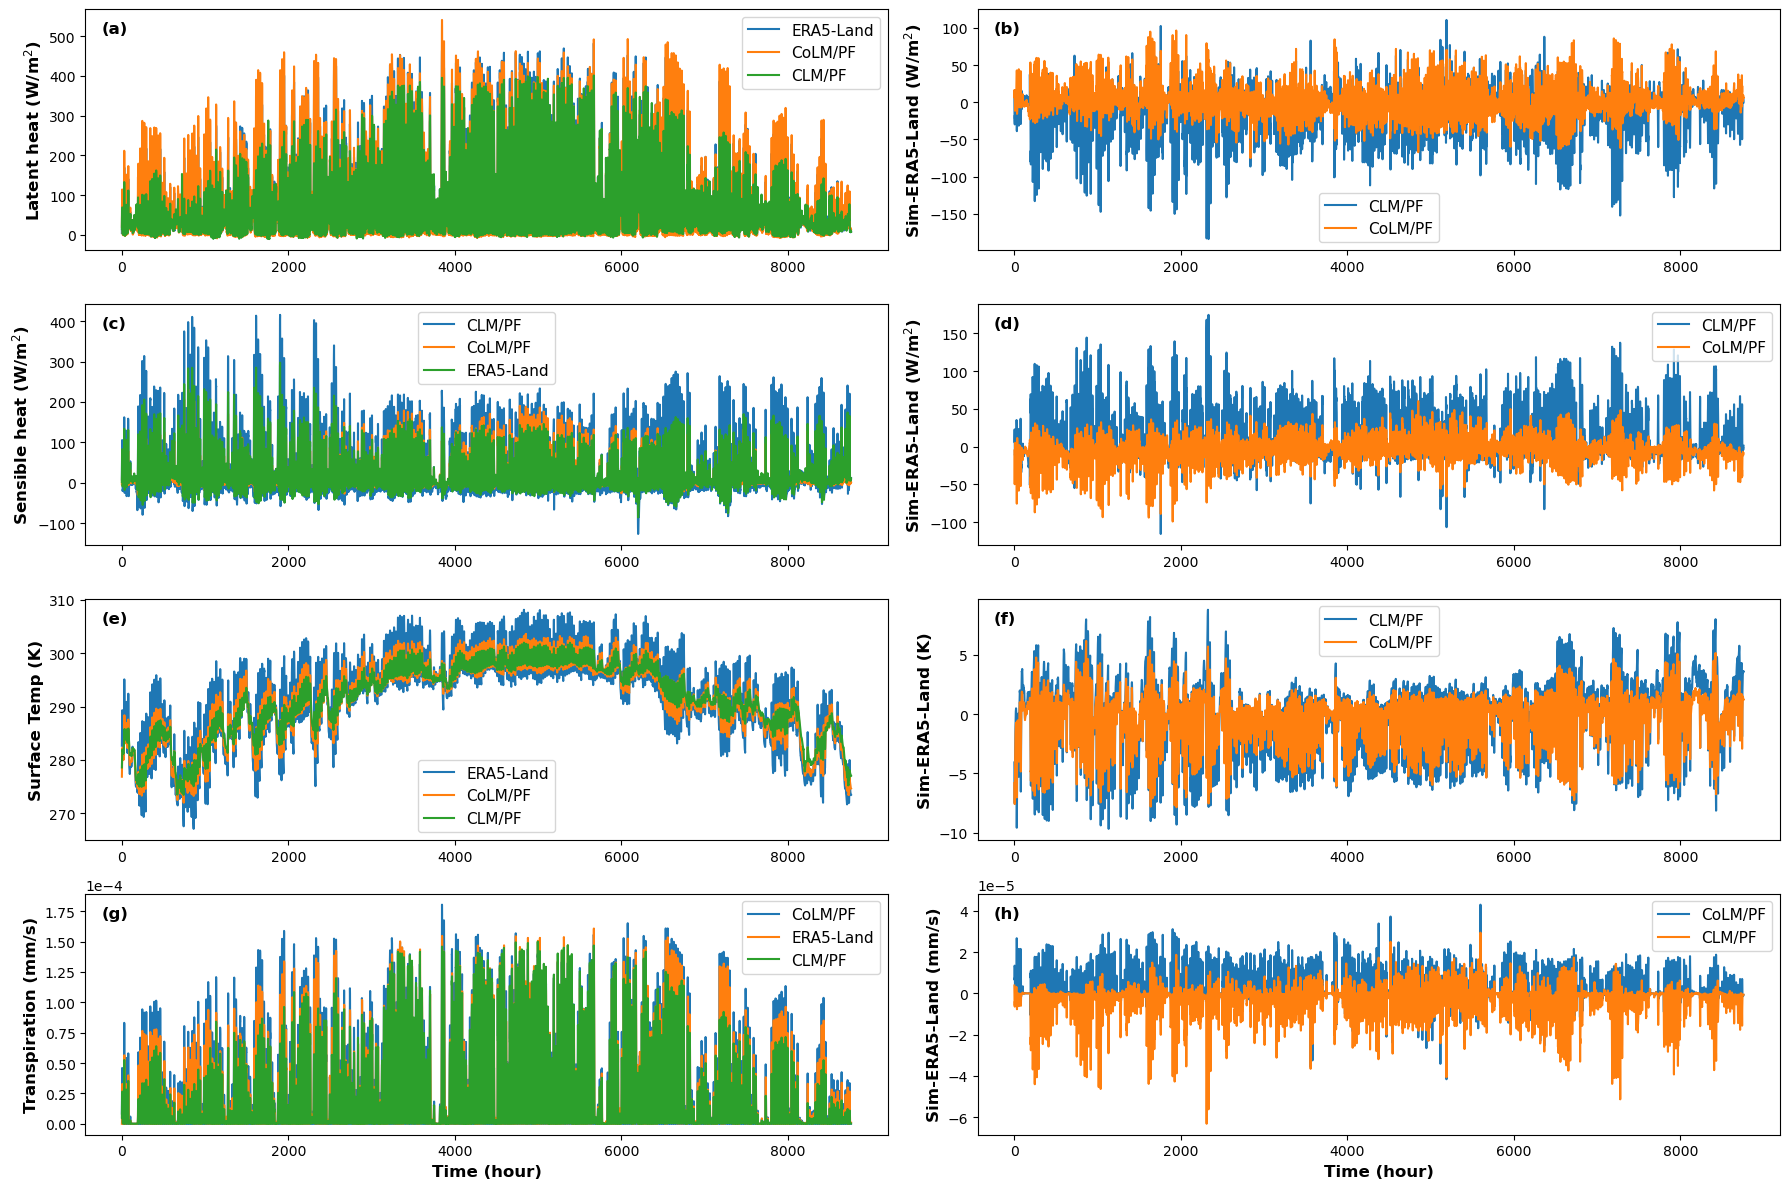

In [5]:
###FIGURE 3

n = 8760

oldlh = np.load('./for_plot_data/lh_tot_230_y2.npy')
newlh = np.load('./for_plot_data/shallow_lh_2nd.npy')
ERAlh = np.load('for_plot_data/ERA5_land_lh_0_8759.npy')

oldsh = np.load('./for_plot_data/sh_tot_230_y2.npy')
newsh = np.load('./for_plot_data/shallow_sh_2nd.npy')
ERAsh = np.load('for_plot_data/ERA5_land_sh_0_8759.npy')

oldst = np.load('./for_plot_data/t_grnd_230_y2.npy')
newst = np.load('./for_plot_data/shallow_st_2nd.npy')
ERAst = np.load('for_plot_data/ERA5_land_skt_0_8759.npy')

oldet = np.load('./for_plot_data/tran_veg_230_y2.npy')
newet = np.load('./for_plot_data/shallow_et_2nd.npy')
ERAet = np.load('for_plot_data/evabs_mean.npy')

# newevapt = np.load('./for_plot_data/shallow_evaptrans_2nd.npy')
# oldevapt = np.load('./for_plot_data/evaptrans_230.npy')

# newsnow = np.load('./for_plot_data/snow_single_new.npy')
# oldsnow = np.load('./for_plot_data/snow_single_old.npy')
# etrdata = np.load('../station_forcing/swe_2003.npy')



fig, axs = plt.subplots(4, 2, figsize=(18, 12))
axs = axs.flatten()  # 方便用一维索引

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

# 子图 1
axs[0].plot(range(1, n), ERAlh[1:n])
axs[0].plot(range(1, n), newlh[n-n:n-1])
axs[0].plot(range(1, n), oldlh[n-n:n-1])
axs[0].legend(['ERA5-Land', 'CoLM/PF', 'CLM/PF'], fontsize=11)
axs[0].set_ylabel('Latent heat (W/m$^2$)', fontsize=12, fontweight='bold')

# 子图 2
axs[1].plot(range(1, n), oldlh[n-n:n-1] - ERAlh[1:n])
axs[1].plot(range(1, n), newlh[n-n:n-1] - ERAlh[1:n])
axs[1].legend(['CLM/PF', 'CoLM/PF'], fontsize=11)
axs[1].set_ylabel('Sim-ERA5-Land (W/m$^2$)', fontsize=12, fontweight='bold')

# 子图 3
axs[2].plot(range(1, n), oldsh[n-n:n-1])
axs[2].plot(range(1, n), newsh[n-n:n-1])
axs[2].plot(range(1, n), ERAsh[1:n])
axs[2].legend(['CLM/PF', 'CoLM/PF', 'ERA5-Land'], fontsize=11)
axs[2].set_ylabel('Sensible heat (W/m$^2$)', fontsize=12, fontweight='bold')

# 子图 4
axs[3].plot(range(1, n), oldsh[n-n:n-1] - ERAsh[1:n])
axs[3].plot(range(1, n), newsh[n-n:n-1] - ERAsh[1:n])
axs[3].legend(['CLM/PF', 'CoLM/PF'], fontsize=11)
axs[3].set_ylabel('Sim-ERA5-Land (W/m$^2$)', fontsize=12, fontweight='bold')

# 子图 5
axs[4].plot(range(1, n), ERAst[1:n])
axs[4].plot(range(1, n), newst[n-n:n-1])
axs[4].plot(range(1, n), oldst[n-n:n-1])
axs[4].legend(['ERA5-Land', 'CoLM/PF', 'CLM/PF'], fontsize=11)
axs[4].set_ylabel('Surface Temp (K)', fontsize=12, fontweight='bold')

# 子图 6
axs[5].plot(range(1, n), oldst[n-n:n-1] - ERAst[1:n])
axs[5].plot(range(1, n), newst[n-n:n-1] - ERAst[1:n])
axs[5].legend(['CLM/PF', 'CoLM/PF'], fontsize=11)
axs[5].set_ylabel('Sim-ERA5-Land (K)', fontsize=12, fontweight='bold')

# 子图 7
axs[6].plot(range(1, n), newet[n-n:n-1])
axs[6].plot(range(1, n), ERAet[n-n:n-1])
axs[6].plot(range(1, n), oldet[n-n:n-1])
axs[6].legend(['CoLM/PF', 'ERA5-Land', 'CLM/PF'], fontsize=11)
axs[6].set_ylabel('Transpiration (mm/s)', fontsize=12, fontweight='bold')
axs[6].set_xlabel('Time (hour)', fontsize=12, fontweight='bold')
axs[6].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# 子图 8
axs[7].plot(range(1, n), newet[n-n:n-1] - ERAet[1:n])
axs[7].plot(range(1, n), oldet[n-n:n-1] - ERAet[1:n])
axs[7].legend(['CoLM/PF', 'CLM/PF'], fontsize=11)
axs[7].set_ylabel('Sim-ERA5-Land (mm/s)', fontsize=12, fontweight='bold')
axs[7].set_xlabel('Time (hour)', fontsize=12, fontweight='bold')

# 添加文字标签 (a)-(h)
for idx, ax in enumerate(axs):
    ax.text(0.02, 0.95, labels[idx], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()

# fig.savefig('figure3.png', dpi=600, bbox_inches='tight')



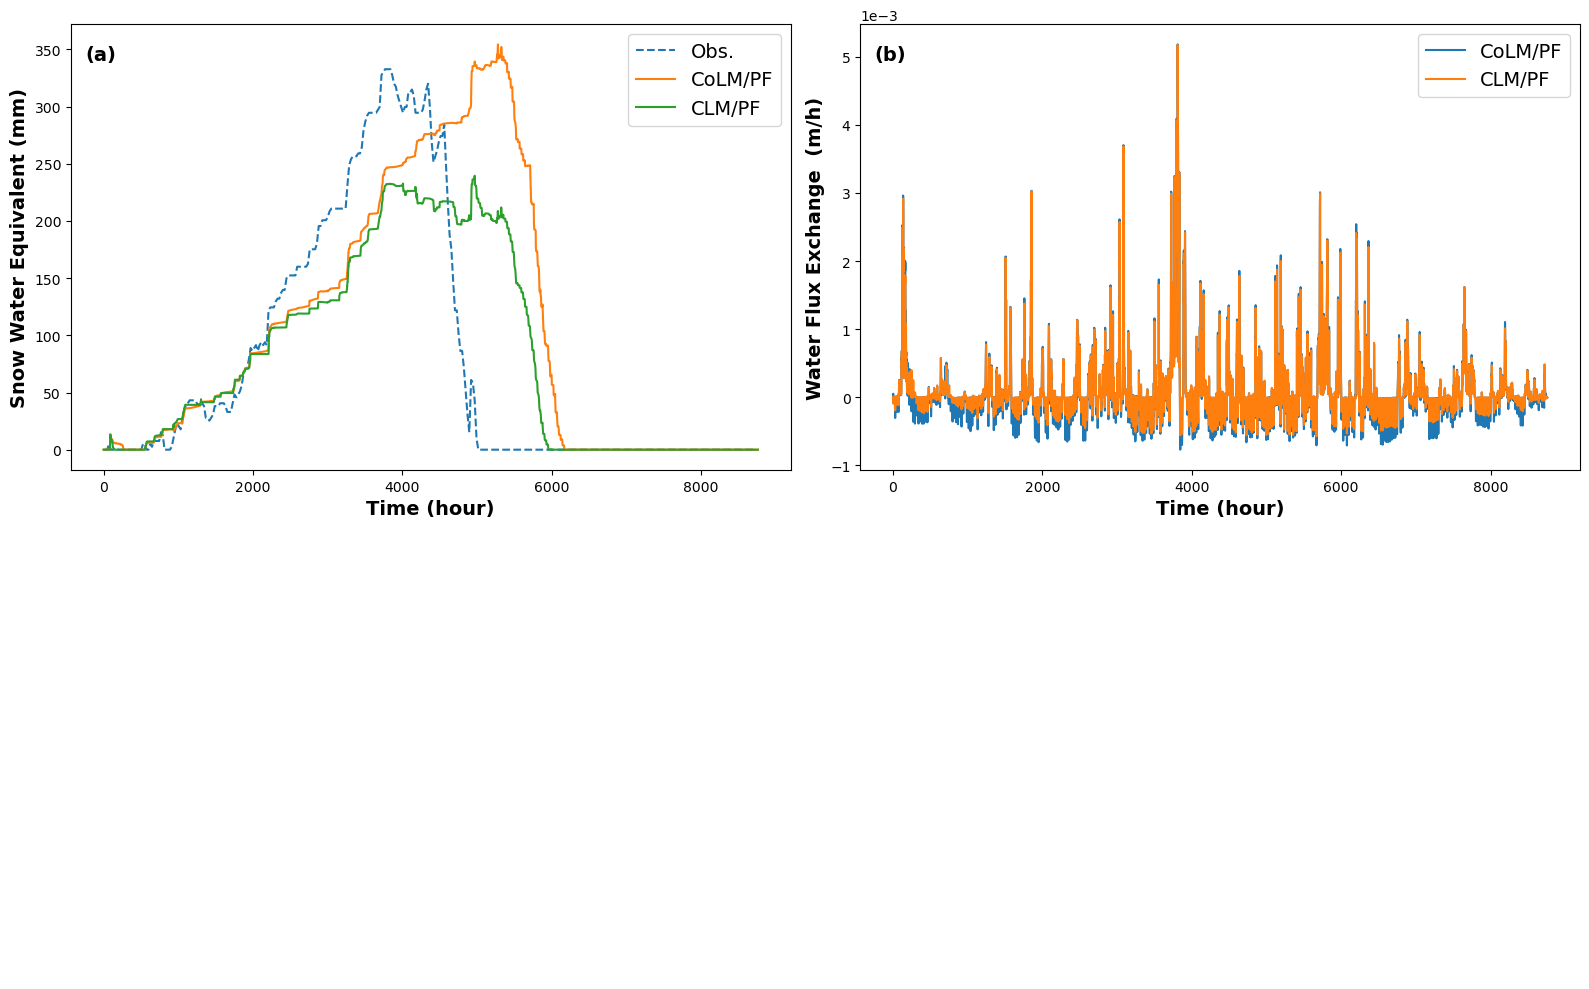

In [6]:
###FIGURE 4
n = 8760


newevapt = np.load('./for_plot_data/shallow_evaptrans_2nd.npy')
oldevapt = np.load('./for_plot_data/evaptrans_230_y2.npy')
# oldevapt2 = np.load('./for_plot_data/evaptrans_230.npy')
# print(np.sum(oldevapt-oldevapt2))

newsnow = np.load('./for_plot_data/snow_single_new.npy')
oldsnow = np.load('./for_plot_data/snow_single_old.npy')
etrdata = np.load('./for_plot_data/swe_2003.npy')


# 创建图像和子图
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# (a) SWE 时间序列
axs[0, 0].plot(range(0, 8760, 24), etrdata[0, :] * 25.4, '--')
axs[0, 0].plot(range(0, n), newsnow)
axs[0, 0].plot(range(0, n), oldsnow)
axs[0, 0].legend(['Obs.', 'CoLM/PF', 'CLM/PF'], fontsize=14)
axs[0, 0].set_ylabel('Snow Water Equivalent (mm)', fontsize=14, fontweight='bold')
axs[0, 0].set_xlabel('Time (hour)', fontsize=14, fontweight='bold')
axs[0, 0].text(0.02, 0.92, '(a)', transform=axs[0, 0].transAxes, fontsize=14, fontweight='bold')

# (b) 地表-地下交换通量
axs[0, 1].plot(range(n), newevapt)
axs[0, 1].plot(range(n), oldevapt)
axs[0, 1].legend(['CoLM/PF', 'CLM/PF'], fontsize=14)
axs[0, 1].set_ylabel('Water Flux Exchange  (m/h)', fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel('Time (hour)', fontsize=14, fontweight='bold')
axs[0, 1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  # 科学记数法
axs[0, 1].text(0.02, 0.92, '(b)', transform=axs[0, 1].transAxes, fontsize=14, fontweight='bold')

# 隐藏未使用的子图
axs[1, 0].axis('off')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

# fig.savefig('figure4.png', dpi=600, bbox_inches='tight')
